# EDA: Queued Up - Dataset of Lawrance Berkely National Labortory (LBNL)

## Table of Content

- [1. Structure and Quality of Data](#1-structure-and-quality-of-data)
- [2. Univariate Analysis](#2-univariate-analysis)
- [3. Bivariate Analysis](#3-bivariate-analysis)
- [4. Time Series Analysis](#4-time-series-analysis)
- [5. Business Logic](#5-business-logic)

In [5]:
%pip install pandas numpy matplotlib seaborn openpyxl sqlalchemy psycopg2-binary ipykernel

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [7]:
sns.set_theme(style="whitegrid")

DATA_PATH = "../data/raw"
FILE_NAME = "LBNL_Queue_Data_25.xlsx"
file_path = os.path.join(DATA_PATH, FILE_NAME)

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"File not found in '{file_path}'. "
        "Look for LBNL 'Queue Up'-Dataset from https://emp.lbl.gov/queues "
        f"and save it under '{DATA_PATH}/'."
    )

raw_sheet = '03. Complete Queue Data'

df = pd.read_excel(file_path, sheet_name=raw_sheet, header=1)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38201 entries, 0 to 38200
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   q_id            38201 non-null  object        
 1   q_status        38201 non-null  object        
 2   q_date          37536 non-null  datetime64[ns]
 3   prop_date       32936 non-null  datetime64[ns]
 4   on_date         3709 non-null   datetime64[ns]
 5   wd_date         15623 non-null  datetime64[ns]
 6   ia_date         4833 non-null   datetime64[ns]
 7   IA_phase_raw    23463 non-null  object        
 8   IA_phase_clean  31034 non-null  object        
 9   county          36138 non-null  object        
 10  state           36966 non-null  object        
 11  fips_code       36431 non-null  float64       
 12  poi_name        35388 non-null  object        
 13  region          38201 non-null  object        
 14  project_name    13088 non-null  object        
 15  ut

## 1. Structure and Quality of Dataset

In [9]:
print(f"Rows and Columns: {df.shape}")
print("\n Datatypes:")
print(df.dtypes)

Rows and Columns: (38201, 30)

 Datatypes:
q_id                      object
q_status                  object
q_date            datetime64[ns]
prop_date         datetime64[ns]
on_date           datetime64[ns]
wd_date           datetime64[ns]
ia_date           datetime64[ns]
IA_phase_raw              object
IA_phase_clean            object
county                    object
state                     object
fips_code                float64
poi_name                  object
region                    object
project_name              object
utility                   object
entity                    object
developer                 object
cluster                   object
service                   object
project_type              object
type_1                    object
type_2                    object
type_3                    object
type_clean                object
mw_1                     float64
mw_2                     float64
mw_3                     float64
q_year                   float64


In [10]:
print("\n Missing Values per Column:")
print(df.isnull().sum())


 Missing Values per Column:
q_id                  0
q_status              0
q_date              665
prop_date          5265
on_date           34492
wd_date           22578
ia_date           33368
IA_phase_raw      14738
IA_phase_clean     7167
county             2063
state              1235
fips_code          1770
poi_name           2813
region                0
project_name      25113
utility            7855
entity                0
developer         29714
cluster           25806
service           10797
project_type       1224
type_1                0
type_2            33144
type_3            38091
type_clean            0
mw_1                  0
mw_2              37105
mw_3              38156
q_year              665
prop_year          5265
dtype: int64


In [11]:
print(f"\n Number of duplicates: {df.duplicated().sum()}")
print(f"Number of double q_ids: {df['q_id'].duplicated().sum()}")
print(f"Number of double q_ids and utility: {df[['q_id', 'utility']].duplicated().sum()}")
print(f"Number of double q_ids and region: {df[['q_id', 'region']].duplicated().sum()}")
print(f"Number of double q_ids, utility and region: {df[['q_id', 'utility', 'region']].duplicated().sum()}")



 Number of duplicates: 0
Number of double q_ids: 7902
Number of double q_ids and utility: 218
Number of double q_ids and region: 3136
Number of double q_ids, utility and region: 203


In [12]:
print("\n Unique Resource-Types (type_clean):")
print(df['type_clean'].value_counts(dropna=False))
print(f"Number of unique resource-types: {len(df['type_clean'].unique())}")


 Unique Resource-Types (type_clean):
type_clean
Solar                          13479
Wind                            6470
Battery                         5826
Solar+Battery                   4451
Gas                             3744
Other                           1767
Hydro                            499
Coal                             446
Offshore Wind                    220
Nuclear                          211
Geothermal                       176
Wind+Battery                     132
Gas+Oil                          113
Other Storage                    111
Diesel                           108
Other+Battery                     84
Oil                               83
Solar+Wind+Battery                75
Gas+Battery                       48
Solar+Other                       29
Solar+Wind                        26
Solar+Gas+Battery                 23
Solar+Gas                         16
Gas+Other                         12
Hydro+Battery                      8
Hydrogen                  

#### Review: Quality and Structure of the dataset

- **Data-Quality**: Dataset has 38.201 Rows and 30 Columns. No missing values in "type_clean". Huge amount of data cleaning was done by LBNL.
- **Identification (Primary Key Problem)**: There are 7.902 duplicates in "q_id". These ids are not global, they are used by the local grid-suppliers. To clearly identify a project, variable-chaining (composite key) is not enough. A **surrogate key** in ETL-pipeline is necassary.

#### Implementation Rate

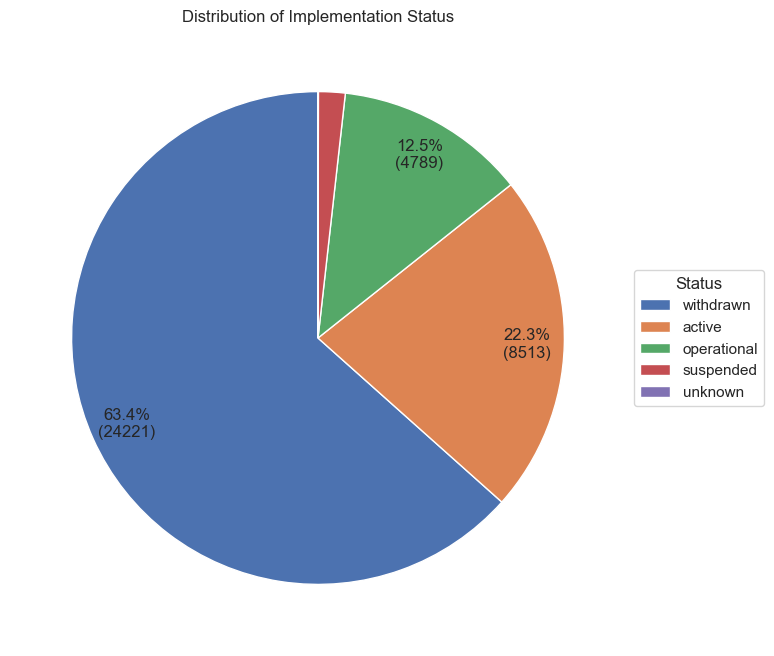

In [13]:
counts = df['q_status'].value_counts(dropna=False)

def autopct_format(values):
    def my_format(pct):
      if pct < 4.0:
        return ''

      total = sum(values)
      val = int(round(pct*total/100.0))
      return f'{pct:.1f}%\n({val})'
    return my_format

# Pie chart
counts.plot(
    kind='pie',
    autopct=autopct_format(counts),
    startangle=90,
    figsize=(8, 8),
    labels=None,
    pctdistance=0.85
    #colors=['#1f77b4', '#ff7f0e', '#2ca02c']
)

# Show pie chart
plt.title('Distribution of Implementation Status')
plt.ylabel('')
plt.legend(labels=counts.index, title="Status", loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

#### Review: Implementation Rate
- Actual Implementation Rate at around 16,5%


## 2. Univariate Analysis

--- Statistical Indicators for mw_1 (Capacity)
count    38201.00
mean       179.06
std        256.65
min        -75.00
25%         30.23
50%        100.00
75%        203.00
max      16875.00
Name: mw_1, dtype: float64


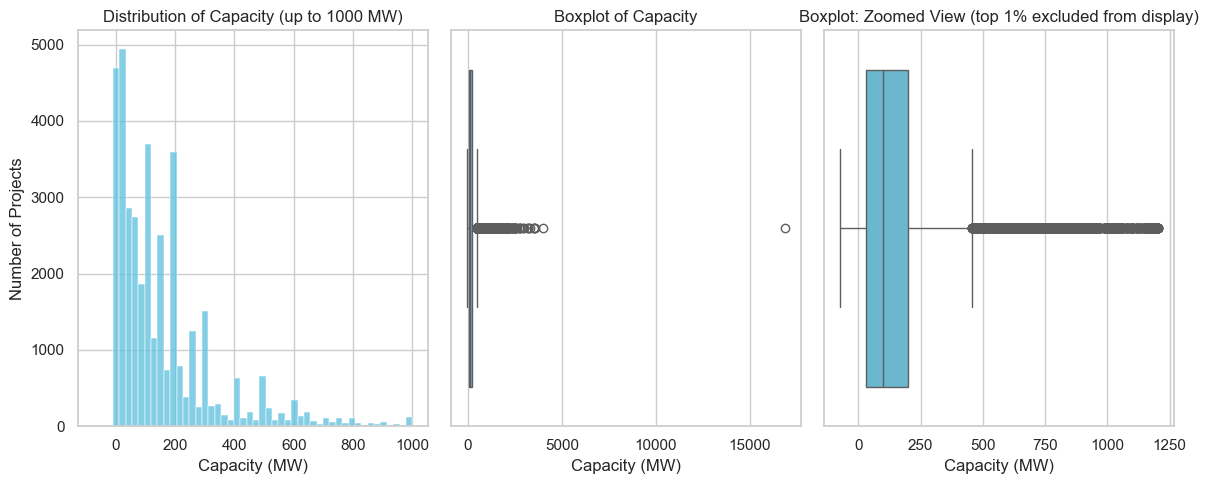


---  The 5 largest Projects ---
                q_id    type_clean     mw_1 state     region
32086             61         Other  16875.0    MS  Southeast
29000   GEN-2008-031          Wind   4000.0    TX        SPP
11014           J292         Hydro   3576.0    MB       MISO
38097  caiso_c15_465  Wind+Battery   3526.0    CA      CAISO
31648            219          Wind   3500.0    TN  Southeast

--- Negative capacity values: ---
       q_id type_clean       mw_1 state  region
6703    148      Hydro -17.000000    NH  ISO-NE
7070    438        Gas -21.200001    MA  ISO-NE
8648   G920       Coal -15.000000    MO    MISO
12978  L002      Other -28.000000    MN    MISO
12979  L003      Other -10.000000    MI    MISO

--- Amount of Projects with negative capacity: ---
Number of projects with negative capacity: 16


In [14]:
print("--- Statistical Indicators for mw_1 (Capacity)")
print(df['mw_1'].describe().round(2))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

sns.histplot(df[df['mw_1'] <= 1000]['mw_1'], bins=50, ax=ax1, color='#5bc0de')
ax1.set_xlabel('Capacity (MW)')
ax1.set_ylabel('Number of Projects')
ax1.set_title('Distribution of Capacity (up to 1000 MW)')

sns.boxplot(x=df['mw_1'], ax=ax2, color='#5bc0de')
ax2.set_xlabel('Capacity (MW)')
ax2.set_title('Boxplot of Capacity')

# Boxplot without the outlier (16.875 MW)
df_zoom = df[df['mw_1'] <= df['mw_1'].quantile(0.99)] # ignore the top 1%
sns.boxplot(x=df_zoom['mw_1'], ax=ax3, color='#5bc0de')
ax3.set_xlabel('Capacity (MW)')
ax3.set_title('Boxplot: Zoomed View (top 1% excluded from display)')


plt.tight_layout()
plt.show()

print("\n---  The 5 largest Projects ---")
print(df.nlargest(5, 'mw_1')[['q_id', 'type_clean', 'mw_1', 'state', 'region']])

print("\n--- Negative capacity values: ---")
print(df[df['mw_1'] < 0][['q_id', 'type_clean', 'mw_1', 'state', 'region']].head())

print("\n--- Amount of Projects with negative capacity: ---")
print(f"Number of projects with negative capacity: {len(df[df['mw_1'] < 0])}")


--- Number of resource types: 49

--- Number of regions in dataset: 9 ---

--- Number of states in dataset: 52 ---


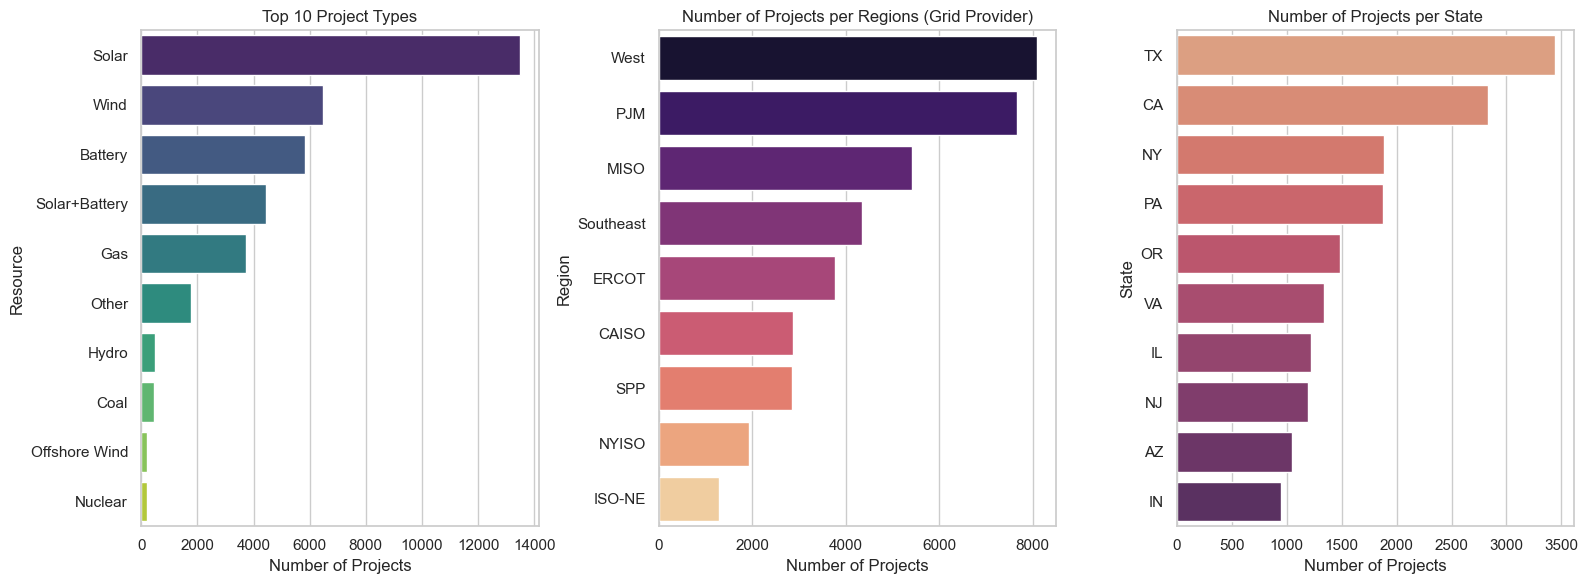

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6))

# Amount of Projects per resource type (top10 resource type)
tech_types = df['type_clean'].value_counts()
print(f"\n--- Number of resource types: {len(tech_types)}")
top_techs = tech_types.head(10)
sns.barplot(x=top_techs.values, y=top_techs.index, ax=ax1, palette='viridis', hue=top_techs.index, legend=False)
ax1.set_title('Top 10 Project Types')
ax1.set_xlabel('Number of Projects')
ax1.set_ylabel('Resource')

# Amount of Projects per region
regions = df['region'].value_counts()
print(f"\n--- Number of regions in dataset: {len(regions)} ---")
top_regions = regions.head(10)
sns.barplot(x=top_regions.values, y=top_regions.index, ax=ax2, palette='magma', hue=top_regions.index, legend=False)
ax2.set_title('Number of Projects per Regions (Grid Provider)')
ax2.set_xlabel('Number of Projects')
ax2.set_ylabel('Region')

# Amount of Projects per state
states = df['state'].value_counts()
print(f"\n--- Number of states in dataset: {len(states)} ---")
top_states = states.head(10)
sns.barplot(x=top_states.values, y=top_states.index, ax=ax3, palette='flare', hue=top_states.index, legend=False)
ax3.set_title('Number of Projects per State')
ax3.set_xlabel('Number of Projects')
ax3.set_ylabel('State')


plt.tight_layout()
plt.show()

#### Review: Univariate Analysis
- Largest project with 16.875 MW in Mississippi (Typ "Other") - possible data entry error
- There are 16 projects with a negative capacity - low impact (<0.05% over all rows)
- Solar, Wind and Battery are dominating in the queue

## 3. Bivariate Analysis

Calculation of the Median Capacity per Technology and visualize it in a Boxplot.



Median Capacity for Top 7 Project Types:
type_clean
Solar             74.500000
Wind             150.000000
Battery          125.000000
Solar+Battery    157.400000
Gas              221.300003
Other             48.000000
Hydro              4.600000
Name: mw_1, dtype: float64


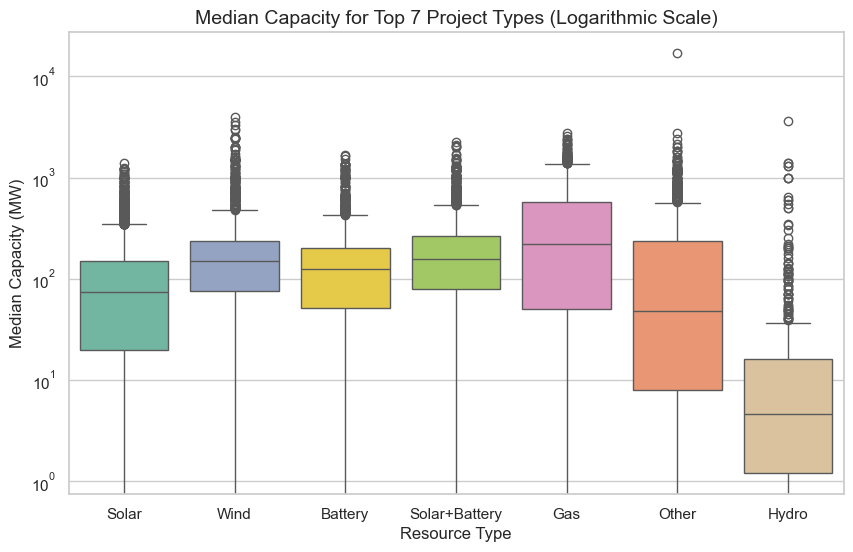

In [16]:
# Calculate median-capacity
top_7_techs = df['type_clean'].value_counts().head(7).index
median_capacity = df.groupby('type_clean')['mw_1'].median().sort_values(ascending=False)

print("Median Capacity for Top 7 Project Types:")
print(median_capacity[top_7_techs])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['type_clean'].isin(top_7_techs)],
            x='type_clean',
            y='mw_1',
            order=top_7_techs,
            palette='Set2',
            hue='type_clean', legend=False)
plt.yscale('log') # log so outlier dont bother
plt.title('Median Capacity for Top 7 Project Types (Logarithmic Scale)', fontsize=14)
plt.xlabel('Resource Type')
plt.ylabel('Median Capacity (MW)')
plt.show()


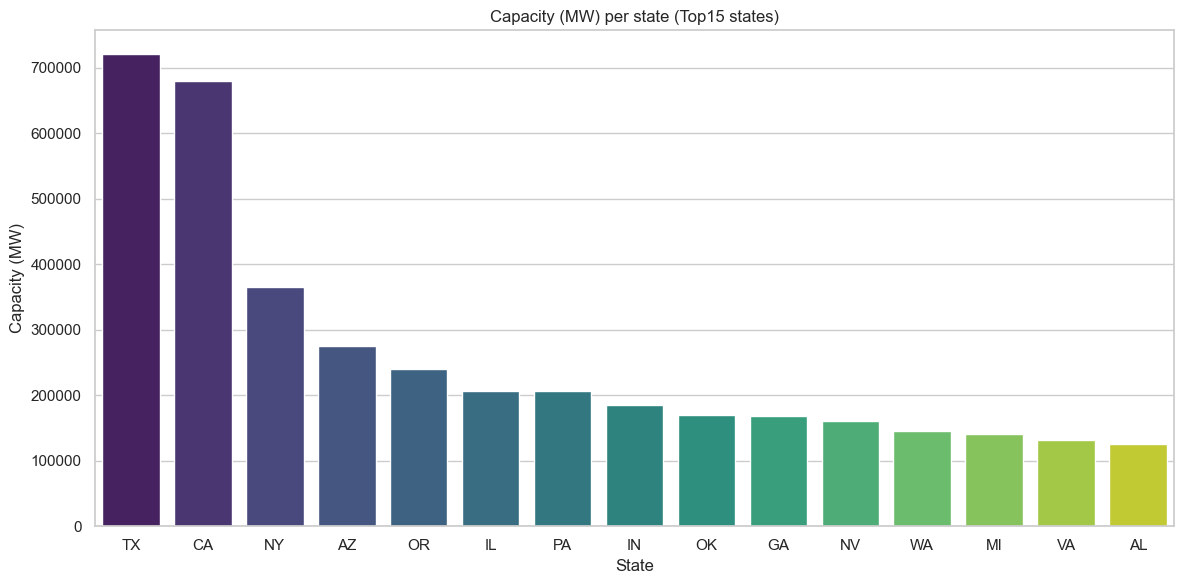

In [29]:
# Capacity per state
capacity_per_state = df.groupby('state')['mw_1'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=capacity_per_state.index, 
            y=capacity_per_state.values, 
            palette='viridis',
            hue=capacity_per_state.index, legend=False)
plt.title('Capacity (MW) per state (Top15 states)')
plt.xlabel('State')
plt.ylabel('Capacity (MW)')
plt.tight_layout()
plt.show()

A heatmap showing which ISO-Region relies on which of the Top-5-Technologies.

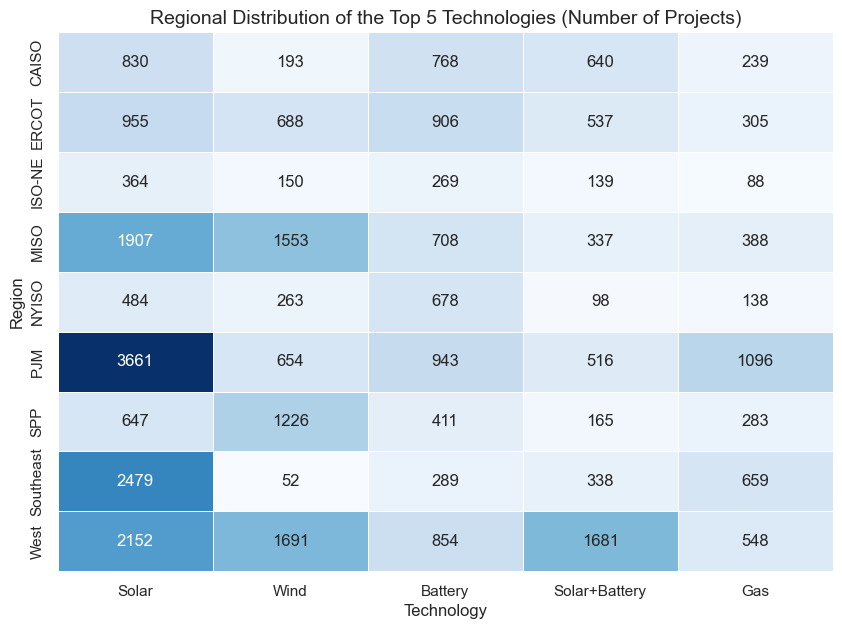

Anzahl echter NaN-Zellen: 0
type_clean  Solar  Wind  Battery  Solar+Battery   Gas
region                                               
CAISO         830   193      768            640   239
ERCOT         955   688      906            537   305
ISO-NE        364   150      269            139    88
MISO         1907  1553      708            337   388
NYISO         484   263      678             98   138
PJM          3661   654      943            516  1096
SPP           647  1226      411            165   283
Southeast    2479    52      289            338   659
West         2152  1691      854           1681   548
Spalten in cross tab: ['Solar', 'Wind', 'Battery', 'Solar+Battery', 'Gas']
top_5_techs: ['Solar', 'Wind', 'Battery', 'Solar+Battery', 'Gas']


In [18]:
top_5_techs = df['type_clean'].value_counts().head(5).index
cross_tab = pd.crosstab(df['region'], df['type_clean'])[top_5_techs]

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cross_tab, cmap='Blues', annot=True, fmt='d', linewidths=0.5, cbar=False)
plt.title('Regional Distribution of the Top 5 Technologies (Number of Projects)', fontsize=14)
plt.xlabel('Technology')
plt.ylabel('Region')
plt.show()

print("Anzahl echter NaN-Zellen:", cross_tab.isna().sum().sum())
print(cross_tab)
print("Spalten in cross tab:", list(cross_tab.columns))
print("top_5_techs:", list(top_5_techs))

#### Review: Bivariate Analysis

- Gas (221 MW) and Solar+Battery (157 MW) are the largest Single-Projects. The smallest is Hydro (4.6 MW)

- Texas and California are the absolute giants in case of planned capacity

- Heatmap Region x Top5-Resources: regional cluster with a focus of ***solar*** in specifs ISOs and ***wind*** in others

- Solar e. g. is big in PJM

## 4. Time Series Analysis
(The Trend Over Time)

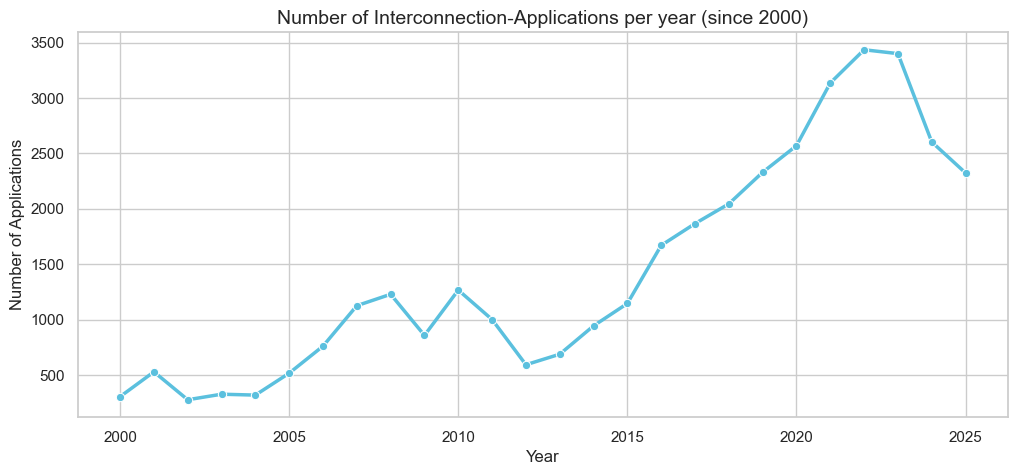

In [19]:
df_years = df[df['q_year'] >= 2000].groupby('q_year').size().reset_index(name='count')

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_years, x='q_year', y='count', marker='o', color='#5bc0de', linewidth=2.5)

plt.title('Number of Interconnection-Applications per year (since 2000)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.grid(True)
plt.show()

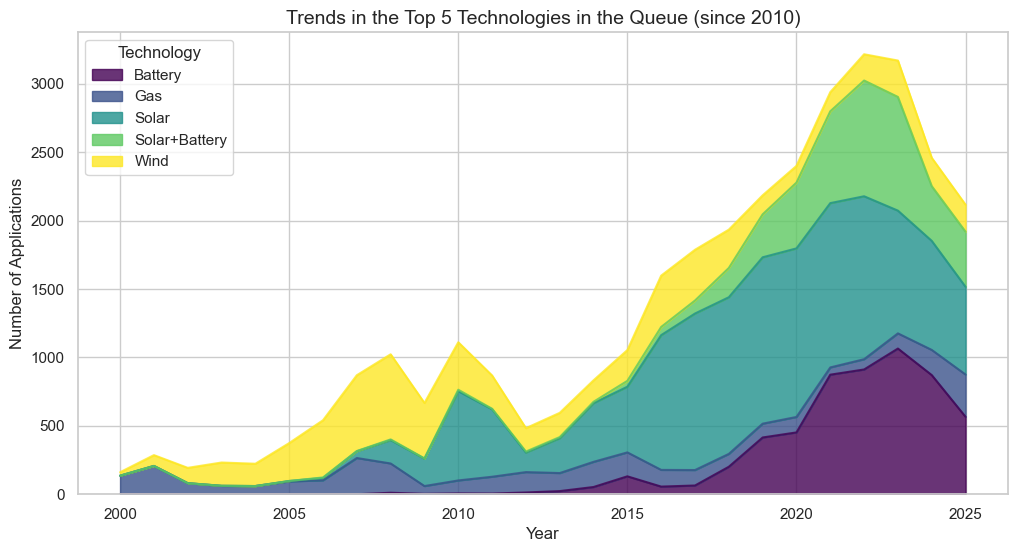

In [20]:
top_5 = ['Solar', 'Wind', 'Battery', 'Solar+Battery', 'Gas']
df_trend = df[(df['type_clean'].isin(top_5)) & (df['q_year'] >= 2000)]

trend_data = df_trend.groupby(['q_year', 'type_clean']).size().unstack(fill_value=0)

trend_data.plot(kind='area', stacked=True, figsize=(12,6), colormap='viridis', alpha=0.8)

plt.title('Trends in the Top 5 Technologies in the Queue (since 2010)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.legend(title='Technology', loc='upper left')
plt.show()

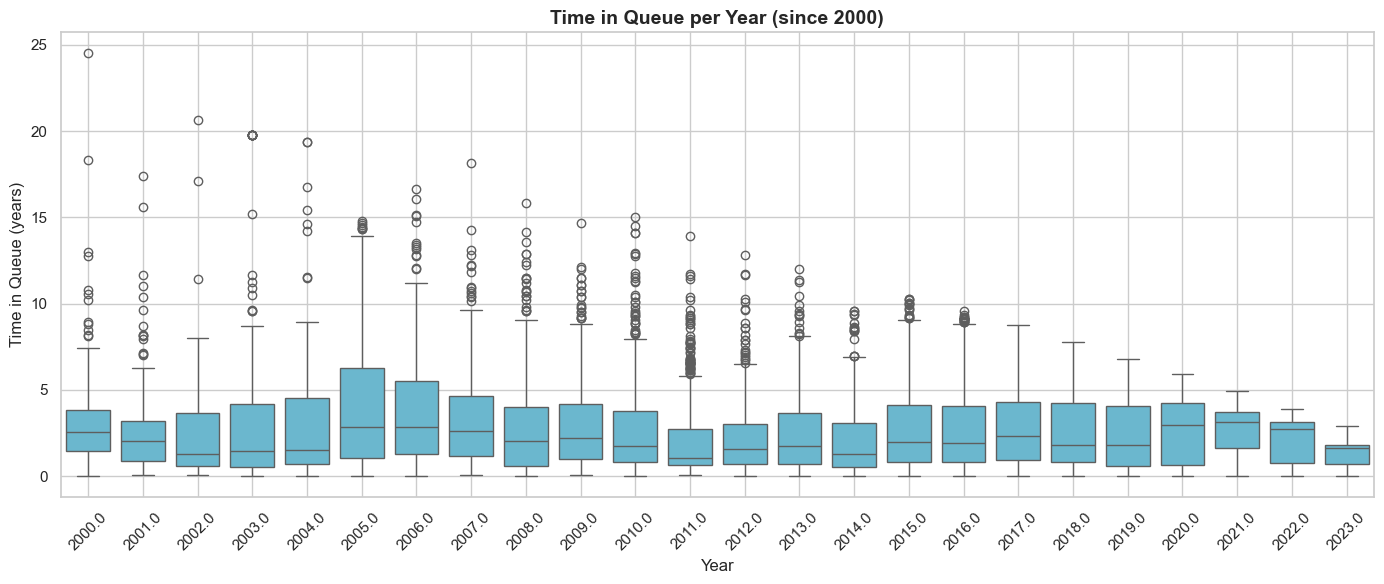

In [21]:
# Time in queue in relation with the application-year
df['end_date'] = df['on_date'].fillna(df['wd_date'])
df['wait_time_years'] = (df['end_date'] - df['q_date']).dt.days / 365.25
df.loc[df['wait_time_years'] < 0, 'wait_time_years'] = np.nan

df_years = df[(df['q_year'] >= 2000) & (df['q_year'] <= 2023)].dropna(subset=['wait_time_years'])

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_years, x='q_year', y='wait_time_years', color='#5bc0de')
plt.title('Time in Queue per Year (since 2000)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Time in Queue (years)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Review: Time Series Analysis

- Number of application per year since 2000: small growth trends in 2012 and 2021

- Wind, solar and the combination of solar+battery have the biggest growth since 2012

- The average time in the queue increased in the past years (Maybe higher demand in energy since the AI-Boom and therefor more applications)

## 5. Business Logic

Calculate Time in queue and identify Anomalies.

In [22]:
df['end_date'] = df['on_date'].fillna(df['wd_date'])

df['wait_time_years'] = (df['end_date'] - df['q_date']).dt.days / 365.25

print("--- Statistical Indicators for wait_time_years ---")
print(df['wait_time_years'].describe().round(2))

# Anomalies (negative time in queue)
print("\n Are there Projects with a negative time in queue? ---")
error_df = df[df['wait_time_years'] < 0]
print(f"Number of projects with negative time in queue: {len(error_df)}")
print(error_df[['q_id', 'q_status', 'q_date', 'end_date', 'wait_time_years']].head())


--- Statistical Indicators for wait_time_years ---
count    18739.00
mean         2.46
std          2.26
min        -24.45
25%          0.77
50%          1.82
75%          3.65
max         24.50
Name: wait_time_years, dtype: float64

 Are there Projects with a negative time in queue? ---
Number of projects with negative time in queue: 56
       q_id     q_status     q_date   end_date  wait_time_years
743      29    withdrawn 2010-07-29 2010-03-24        -0.347707
1822   1040  operational 2014-04-30 2014-01-03        -0.320329
3244  643AB    withdrawn 2010-07-31 2010-07-26        -0.013689
3647     98  operational 2006-03-09 2005-12-31        -0.186174
3999    100  operational 2009-04-15 2009-01-31        -0.202601


Check whether there is a correlation between capacity and time in queue.
Correlation in project space

Correlation between capacity (MW) and time in queue: 0.025


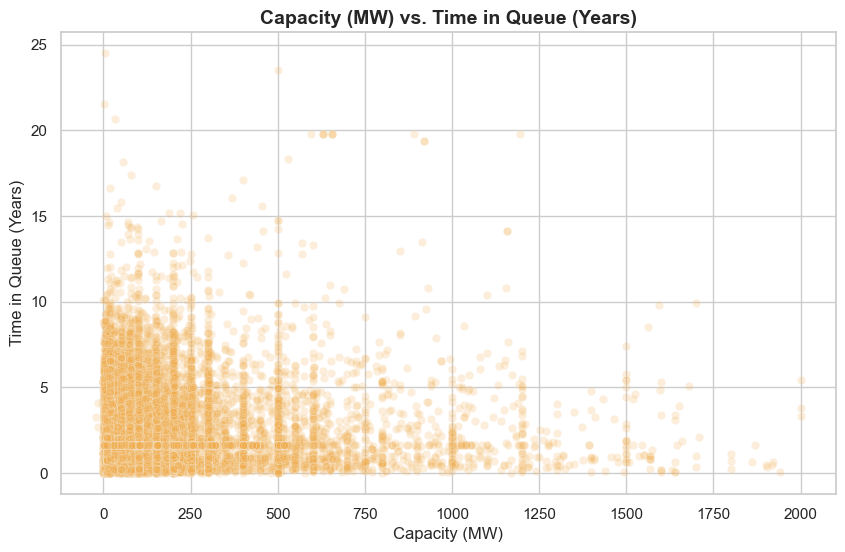

In [23]:
df_clean_wait = df[df['wait_time_years'] >= 0]

correlation = df_clean_wait['mw_1'].corr(df_clean_wait['wait_time_years'])
print(f"Correlation between capacity (MW) and time in queue: {correlation:.3f}")

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_clean_wait[df_clean_wait['mw_1'] <= 2000],
                x='mw_1', y='wait_time_years',
                alpha=0.2, color='#f0ad4e')

plt.title('Capacity (MW) vs. Time in Queue (Years)', fontsize=14, fontweight='bold')
plt.xlabel('Capacity (MW)')
plt.ylabel('Time in Queue (Years)')
plt.grid(True)
plt.show()

Correlation in the regional space

Regional correlation: 0.145



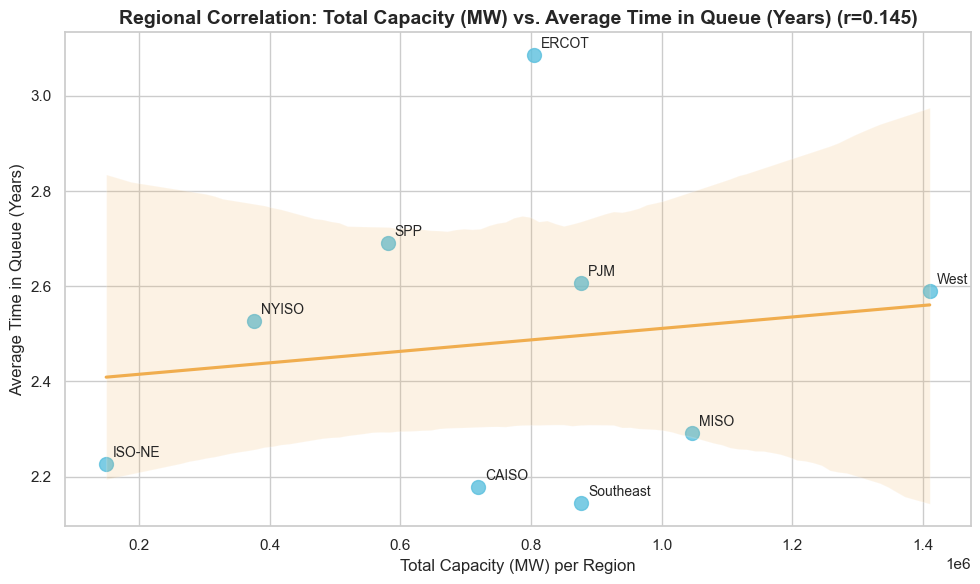

In [24]:
df['end_date'] = df['on_date'].fillna(df['wd_date'])
df['wait_time_years'] = (df['end_date'] - df['q_date']).dt.days / 365.25
df.loc[df['wait_time_years'] < 0, 'wait_time_years'] = np.nan

# Aggregate regional data
region_agg = df.groupby('region').agg(
    total_mw = ('mw_1', 'sum'),
    avg_time = ('wait_time_years', 'mean')
).dropna()

# Calculate Pearson-Correlation
correlation = region_agg['total_mw'].corr(region_agg['avg_time'])
print(f"Regional correlation: {correlation:.3f}\n")

# Scatterplot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(data=region_agg, x='total_mw', y='avg_time',
            scatter_kws={'s': 100, 'color': '#5bc0de'},
            line_kws={'color': '#f0ad4e'})

# Labeling each region
for region, row in region_agg.iterrows():
  plt.annotate(region, (row['total_mw'], row['avg_time']),
               textcoords="offset points",
               xytext=(5, 5), fontsize=10)

plt.title(f"Regional Correlation: Total Capacity (MW) vs. Average Time in Queue (Years) (r={correlation:.3f})",
          fontsize=14, fontweight='bold')
plt.xlabel('Total Capacity (MW) per Region')
plt.ylabel('Average Time in Queue (Years)')
plt.grid(True)
plt.tight_layout()
plt.show()

Time in queue per resource type

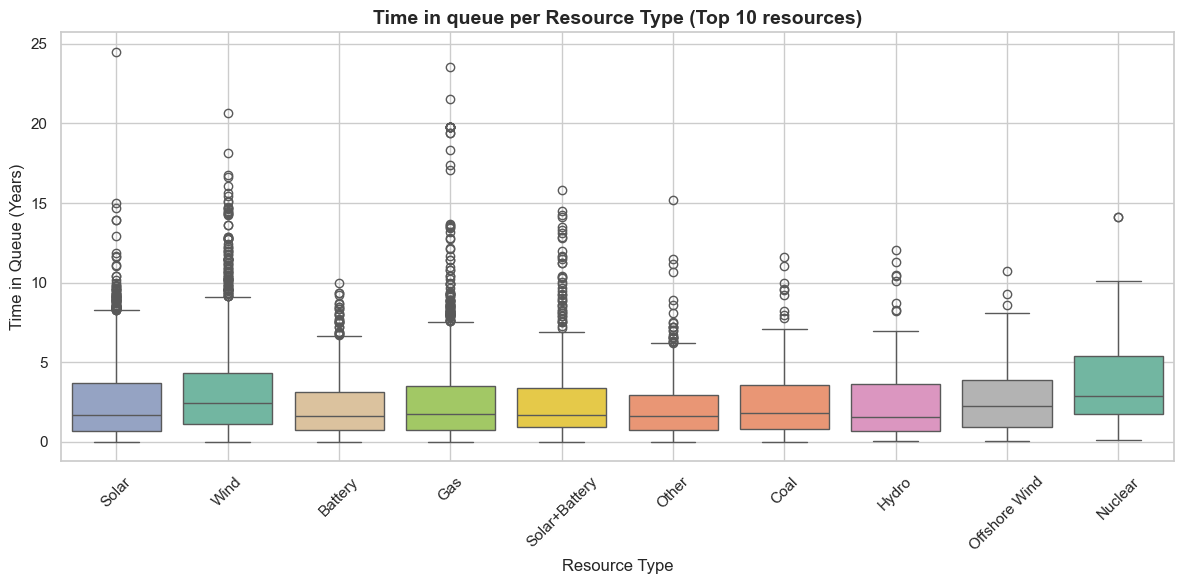


--- Median time in queue per resource type ---
type_clean
Nuclear          2.90
Wind             2.43
Offshore Wind    2.26
Coal             1.82
Gas              1.77
Solar            1.70
Solar+Battery    1.68
Battery          1.63
Other            1.60
Hydro            1.59
Name: wait_time_years, dtype: float64


In [28]:
df_clean_wait = df.dropna(subset=['wait_time_years'])

top_techs = df_clean_wait['type_clean'].value_counts().head(10).index
df_plot = df_clean_wait[df_clean_wait['type_clean'].isin(top_techs)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot,
            x='type_clean',
            y='wait_time_years',
            order=top_techs,
            palette='Set2',
            hue='type_clean', legend=False
            )

plt.title('Time in queue per Resource Type (Top 10 resources)', fontsize=14, fontweight='bold')
plt.xlabel('Resource Type')
plt.ylabel('Time in Queue (Years)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Table with exact medians
print("\n--- Median time in queue per resource type ---")
print(df_plot.groupby('type_clean')['wait_time_years'].median().sort_values(ascending=False).round(2))

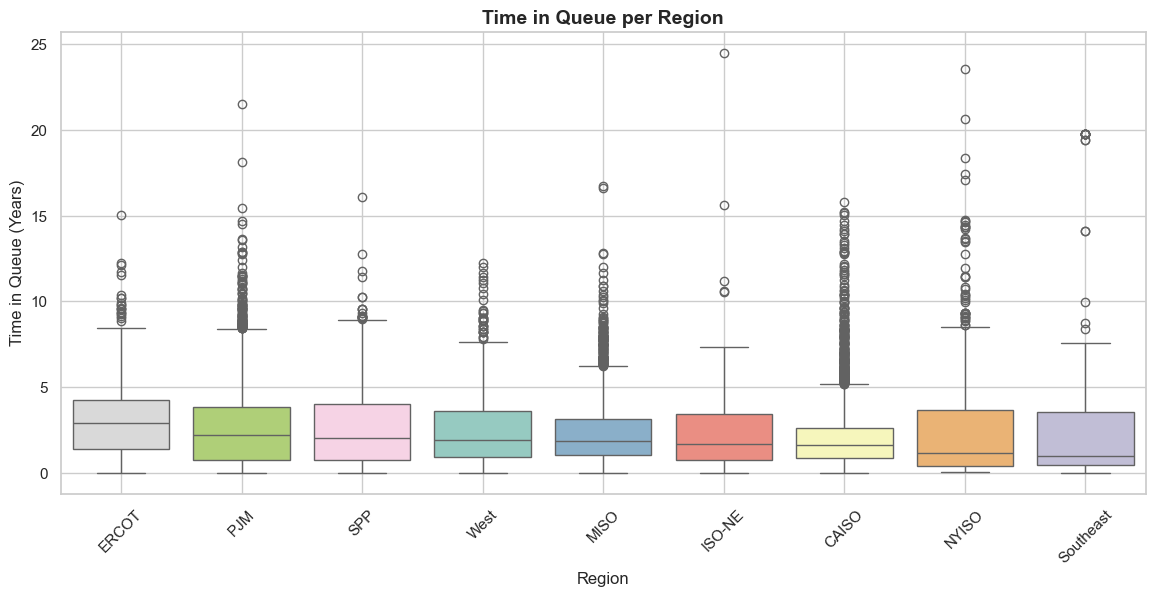

--- Median time in queue per region (years) ---
region
ERCOT        2.90
PJM          2.19
SPP          2.04
West         1.92
MISO         1.83
ISO-NE       1.69
CAISO        1.63
NYISO        1.15
Southeast    1.00
Name: wait_time_years, dtype: float64


In [27]:
# Time in queue in relation with the region
df_region_wait = df.dropna(subset=['wait_time_years', 'region'])

region_order = df_region_wait.groupby('region')['wait_time_years'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_region_wait,
            x='region', y='wait_time_years',
            order=region_order,
            palette='Set3',
            hue='region', legend=False)
plt.title('Time in Queue per Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Time in Queue (Years)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout
plt.show()

# Data in numbers
print("--- Median time in queue per region (years) ---")
print(df_region_wait.groupby('region')['wait_time_years'].median().sort_values(ascending=False).round(2))

#### Review: Business-Logic

- 56 projects exist with a negative time in queue (end-date before start-date) identified - those values were changed to NaN to preserve capacity data, instead of dropping them

- Correlation (Capacity x time in queue): r = 0.025 - practical no Correlation between these two

- Correlation Regions (Capacity x time in queue per region): r = 0.145 - weak positve. Key finding: confirms assumption of independence in the dashboards risk score and can therefore be weighted separately in a meaningful way.

- Nuclear (2.82 years) and wind (2.43 years) with longest time in queue - hydro (1.58 years) with the shortest

- ERCOT (2.90 years) has the longest, Southeast (1.00 years) the shortest time in queue